# 90 Days Violation
## 1.0 not looking at exeptions, just displaying how many appartments are rented for more than 90 days / year

In [2]:
import pandas as pd
listings = pd.read_csv(r"C:\Users\ThinkPad\Desktop\Mastermind\Inside_Airbnb_Berlin\Data\listings.csv")
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14274 non-null  int64  
 1   listing_url                                   14274 non-null  str    
 2   scrape_id                                     14274 non-null  int64  
 3   last_scraped                                  14274 non-null  str    
 4   source                                        14274 non-null  str    
 5   name                                          14274 non-null  str    
 6   description                                   13712 non-null  str    
 7   neighborhood_overview                         6474 non-null   str    
 8   picture_url                                   14274 non-null  str    
 9   host_id                                       14274 non-null  int64  
 1

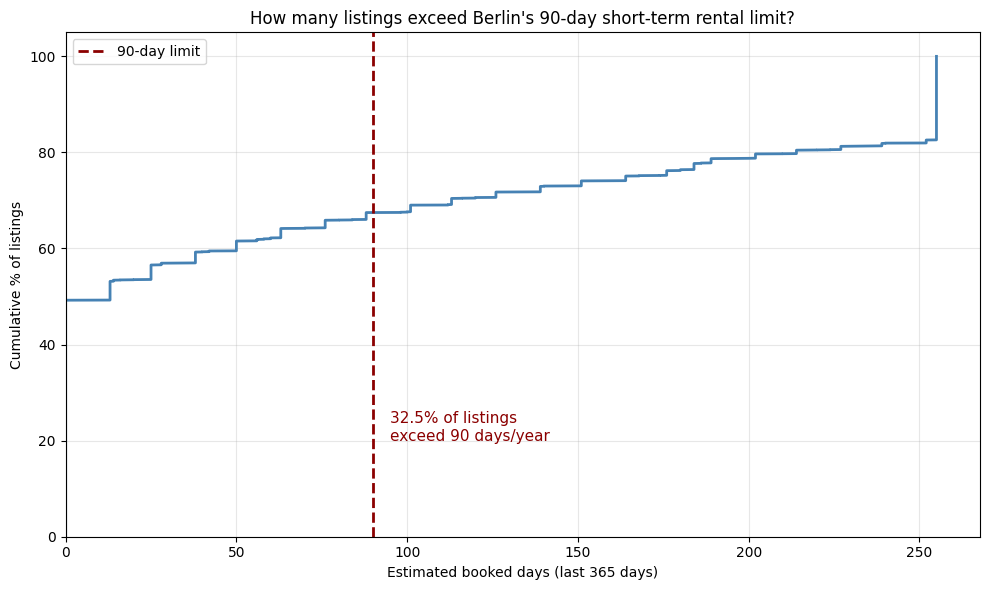

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Plotting_output/SelmasPlots", exist_ok=True)

occ = listings["estimated_occupancy_l365d"].dropna().sort_values().values
ecdf = np.arange(1, len(occ) + 1) / len(occ) * 100



plt.figure(figsize=(10, 6))
plt.plot(occ, ecdf, color="steelblue", linewidth=2)

# Berlin's 90-day rule: short-term rentals beyond 90 days/year typically require permits
plt.axvline(90, color="darkred", linestyle="--", linewidth=2, label="90-day limit")

# Find what % of listings are below the line
pct_below_90 = (occ <= 90).mean() * 100
plt.text(95, 20, f"{100 - pct_below_90:.1f}% of listings\nexceed 90 days/year",
         color="darkred", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.margins(0)

plt.xlabel("Estimated booked days (last 365 days)")
plt.ylabel("Cumulative % of listings")
plt.title("How many listings exceed Berlin's 90-day short-term rental limit?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Plotting_output/SelmasPlots/occupancy_ecdf_all.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# why steps? -> based on estimated data. only 80 nunique

print(listings["estimated_occupancy_l365d"].value_counts().sort_index().head(20))
print(listings["estimated_occupancy_l365d"].nunique())

estimated_occupancy_l365d
0     7028
13     560
14      35
16       8
18       1
20       7
22       1
25     434
26       1
28      53
30       3
32       1
38     326
40       9
42      24
48       2
50     293
52       1
54       1
56      46
Name: count, dtype: int64
80


## Backgroudn information of the 90 days violation

#### 90-day rule — key facts

* Berlin-specific (via Zweckentfremdungsverbot), not Germany-wide; other cities differ (Munich 56 days, Hamburg bans commercial whole-flats).
* Cap applies to secondary residences: max 90 short-term days/year + permit. Primary residence (where you're registered) has no day cap, just a registration number.
* "Short-term" = under 90 consecutive days. A single 90+ day booking is a normal tenancy, outside the rule.
* Enforced by the Bezirksamt (since March 2026: Fachbereich Stadterneuerung). Fines up to €500,000; both host and platform liable.
* Weak follow-through: of €12.4M fined since 2014, only €4.2M collected, mainly due to staff shortages. May 2026 EU data-sharing law is tightening this.
* Report suspected misuse: https://service.berlin.de/dienstleistung/352954/
* Common evasion: high minimum_nights to look long-term, splitting flats across listings/accounts, missing/shared registration numbers, listing as "private room."

### Data processing ideas (your listings)

* ECDF (Empirical Cumulative Distribution Function) of availability_365 with 90-day line → share of listings that could exceed the limit (your current plot).
* minimum_nights >= 90 → flag listings posing as long-term.
* license value_counts(dropna=False) → how many lack a registration number.
* host_listings_count / calculated_host_listings_count > 1 → likely secondary/commercial operators.
* calculated_host_listings_count_entire_homes vs _private_rooms → portfolio shape.
* room_type → entire-home = most regulated.
* neighbourhood_group_cleansed → enforcement/concentration by Bezirk.
* Not derivable: true primary-vs-secondary status, and whether a permit is genuinely valid.

## Filterin out listings that have not been booked in the last year

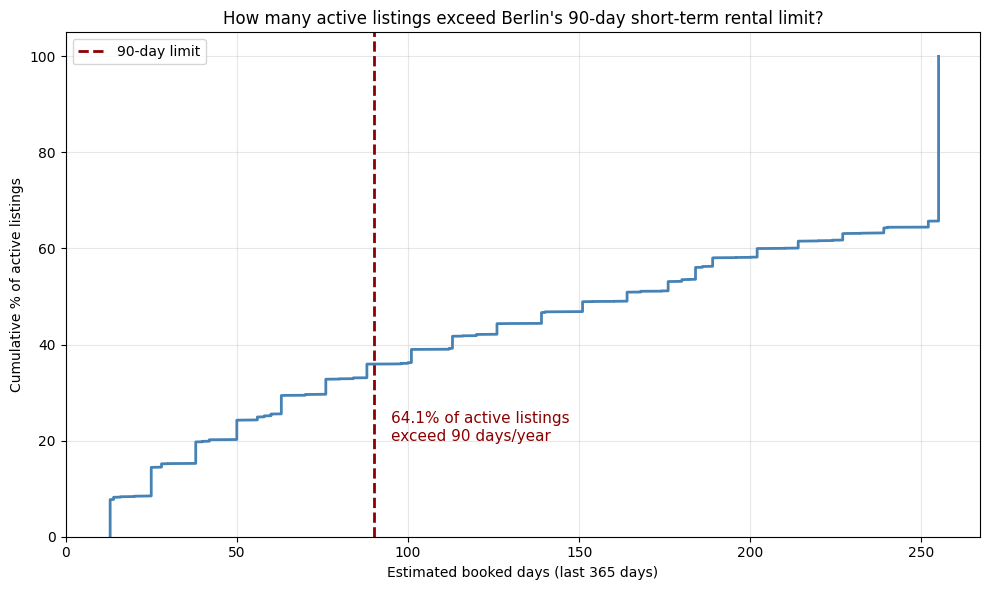

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Plotting_output/SelmasPlots", exist_ok=True)

occ = listings.loc[listings["estimated_occupancy_l365d"] > 0,
                   "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf = np.arange(1, len(occ) + 1) / len(occ) * 100

plt.figure(figsize=(10, 6))
plt.plot(occ, ecdf, color="steelblue", linewidth=2)

# Berlin's 90-day rule: short-term rentals beyond 90 days/year typically require permits
plt.axvline(90, color="darkred", linestyle="--", linewidth=2, label="90-day limit")

# Find what % of listings are below the line
pct_below_90 = (occ <= 90).mean() * 100
plt.text(95, 20, f"{100 - pct_below_90:.1f}% of active listings\nexceed 90 days/year",
         color="darkred", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.margins(0)

plt.xlabel("Estimated booked days (last 365 days)")
plt.ylabel("Cumulative % of active listings")
plt.title("How many active listings exceed Berlin's 90-day short-term rental limit?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Plotting_output/SelmasPlots/occupancy_ecdf_Filtered0bookingsOut.png", bbox_inches="tight", dpi=150)
plt.show()

In [13]:
print(listings["room_type"].value_counts(dropna=False))

room_type
Entire home/apt    9663
Private room       4399
Hotel room          110
Shared room         102
Name: count, dtype: int64


## Filtering steps (to isolate listings the 90-day rule actually targets)
* estimated_occupancy_l365d == 0  -> no booked days, inactive listing
* room_type != "Entire home/apt"  -> private/hotel/shared rooms not covered by the rule
* min_nights >= 90                -> single long-term stays count as normal tenancy, exempt


-> next code shows how many listings are dropped for each category (one listing can apply to multiple categorys)

In [5]:
n0 = len(listings)
print(f"Start:                                {n0:>6}")

# Individually: how many rows each criterion matches (with overlap)
c_inactive = (listings["estimated_occupancy_l365d"] == 0).sum()
c_roomtype = (listings["room_type"] != "Entire home/apt").sum()
c_longterm = (listings["minimum_nights"] >= 90).sum()
print(f"\nMatched individually (with overlap):")
print(f"  estimated_occupancy_l365d == 0:     {c_inactive:>6}")
print(f"  room_type != Entire home/apt:       {c_roomtype:>6}")
print(f"  minimum_nights >= 90:               {c_longterm:>6}")

# Cumulatively: apply filters one after another
df = listings.copy()

df = df[df["estimated_occupancy_l365d"] != 0]
print(f"\nAfter dropping inactive:              {len(df):>6}  (-{n0 - len(df)})")

before = len(df)
df = df[df["room_type"] == "Entire home/apt"]
print(f"After dropping non-entire-home:       {len(df):>6}  (-{before - len(df)})")

before = len(df)
df = df[df["minimum_nights"] < 90]
print(f"After dropping long-term (>=90):      {len(df):>6}  (-{before - len(df)})")

print(f"\nRemaining:                            {len(df):>6}  ({len(df)/n0*100:.1f}% of start)")

Start:                                 14274

Matched individually (with overlap):
  estimated_occupancy_l365d == 0:       7028
  room_type != Entire home/apt:         4611
  minimum_nights >= 90:                 5425

After dropping inactive:                7246  (-7028)
After dropping non-entire-home:         5140  (-2106)
After dropping long-term (>=90):        4837  (-303)

Remaining:                              4837  (33.9% of start)


# plot showing both (before and after filter)
- but with %

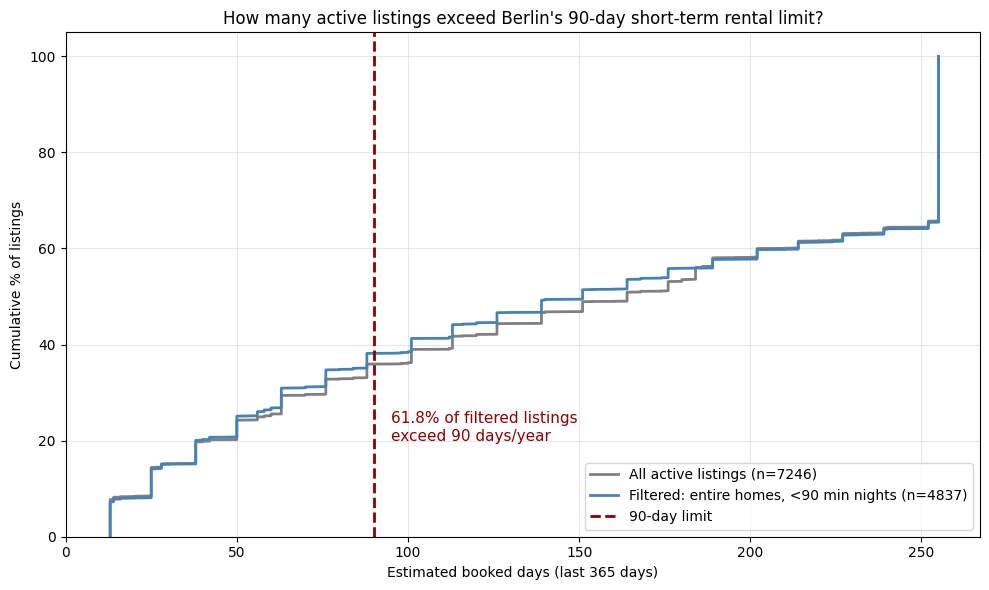

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Plotting_output/SelmasPlots", exist_ok=True)

# Line 1: all active listings (occupancy > 0)
occ_all = listings.loc[listings["estimated_occupancy_l365d"] > 0,
                       "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_all = np.arange(1, len(occ_all) + 1) / len(occ_all) * 100

# Line 2: filtered set (entire homes only, minimum_nights < 90, occupancy > 0)
mask = (
    (listings["estimated_occupancy_l365d"] > 0)
    & (listings["room_type"] == "Entire home/apt")
    & (listings["minimum_nights"] < 90)
)
occ_filt = listings.loc[mask, "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_filt = np.arange(1, len(occ_filt) + 1) / len(occ_filt) * 100

plt.figure(figsize=(10, 6))
plt.plot(occ_all, ecdf_all, color="gray", linewidth=2,
         label=f"All active listings (n={len(occ_all)})")
plt.plot(occ_filt, ecdf_filt, color="steelblue", linewidth=2,
         label=f"Filtered: entire homes, <90 min nights (n={len(occ_filt)})")

# Berlin's 90-day rule
plt.axvline(90, color="darkred", linestyle="--", linewidth=2, label="90-day limit")

# % exceeding for the filtered set
pct_above_90 = (occ_filt > 90).mean() * 100
plt.text(95, 20, f"{pct_above_90:.1f}% of filtered listings\nexceed 90 days/year",
         color="darkred", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.margins(0)

plt.xlabel("Estimated booked days (last 365 days)")
plt.ylabel("Cumulative % of listings")
plt.title("How many active listings exceed Berlin's 90-day short-term rental limit?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Plotting_output/SelmasPlots/occupancy_ecdf_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

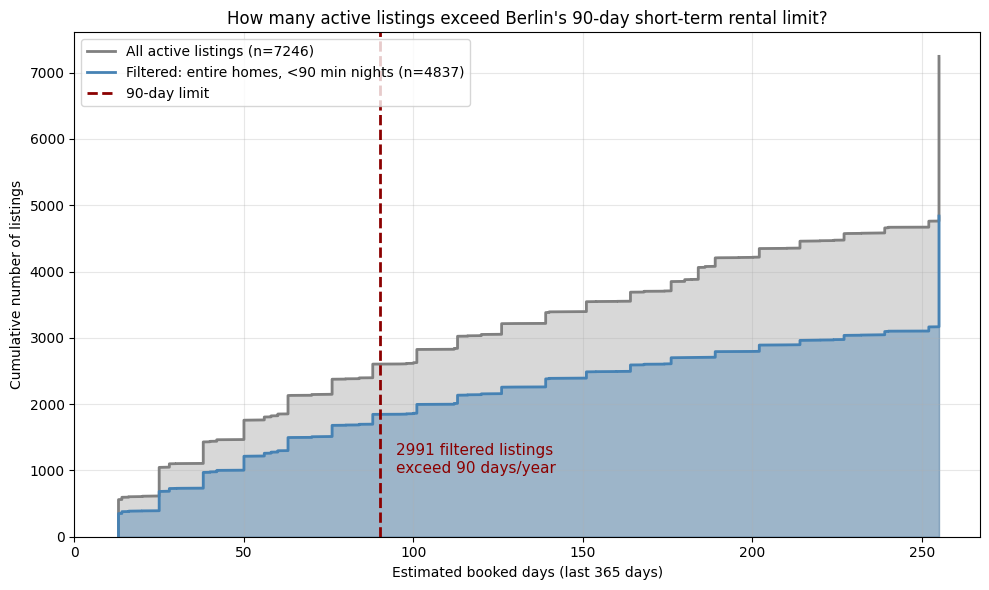

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Plotting_output/SelmasPlots", exist_ok=True)

# Line 1: all active listings (occupancy > 0)
occ_all = listings.loc[listings["estimated_occupancy_l365d"] > 0,
                       "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_all = np.arange(1, len(occ_all) + 1)

# Line 2: filtered set (entire homes only, minimum_nights < 90, occupancy > 0)
mask = (
    (listings["estimated_occupancy_l365d"] > 0)
    & (listings["room_type"] == "Entire home/apt")
    & (listings["minimum_nights"] < 90)
)
occ_filt = listings.loc[mask, "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_filt = np.arange(1, len(occ_filt) + 1)

plt.figure(figsize=(10, 6))

# filled areas (larger group first so it sits behind)
plt.fill_between(occ_all, ecdf_all, color="gray", alpha=0.3)
plt.fill_between(occ_filt, ecdf_filt, color="steelblue", alpha=0.4)

# outlines on top for clarity
plt.plot(occ_all, ecdf_all, color="gray", linewidth=2,
         label=f"All active listings (n={len(occ_all)})")
plt.plot(occ_filt, ecdf_filt, color="steelblue", linewidth=2,
         label=f"Filtered: entire homes, <90 min nights (n={len(occ_filt)})")

# Berlin's 90-day rule
plt.axvline(90, color="darkred", linestyle="--", linewidth=2, label="90-day limit")

# Count exceeding for the filtered set
n_above_90 = (occ_filt > 90).sum()
plt.text(95, len(occ_filt) * 0.2, f"{n_above_90} filtered listings\nexceed 90 days/year",
         color="darkred", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.margins(0)

plt.xlabel("Estimated booked days (last 365 days)")
plt.ylabel("Cumulative number of listings")
plt.title("How many active listings exceed Berlin's 90-day short-term rental limit?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Plotting_output/SelmasPlots/occupancy_ecdf_comparison_filled.png", bbox_inches="tight", dpi=150)
plt.show()

## Looking at calculated_host_listings_count == 1

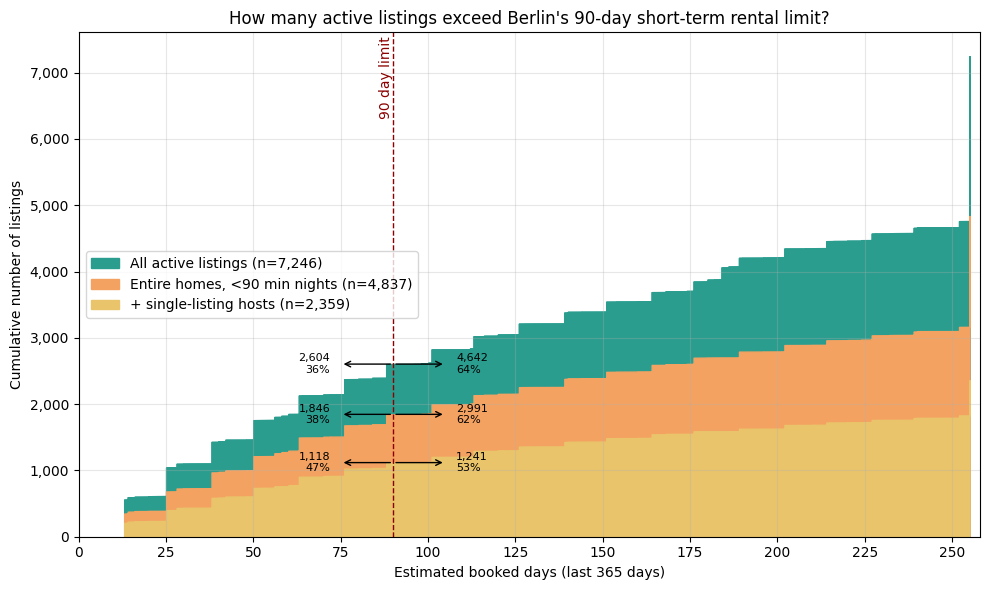

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

os.makedirs("../Plotting_output/SelmasPlots", exist_ok=True)

# --- Build the three cumulative series (x = booked days, y = cumulative count) ---

# Group 1: all active listings (any booked days)
occ_all = listings.loc[listings["estimated_occupancy_l365d"] > 0,
                       "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_all = np.arange(1, len(occ_all) + 1)          # running count 1,2,3,... = cumulative listings

# Group 2: listings the rule actually targets (entire homes, short minimum stay)
mask_filt = (
    (listings["estimated_occupancy_l365d"] > 0)
    & (listings["room_type"] == "Entire home/apt")
    & (listings["minimum_nights"] < 90)
)
occ_filt = listings.loc[mask_filt, "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_filt = np.arange(1, len(occ_filt) + 1)

# Group 3: same as group 2, but only single-listing hosts (proxy for primary residence)
mask_single = mask_filt & (listings["calculated_host_listings_count"] == 1)
occ_single = listings.loc[mask_single, "estimated_occupancy_l365d"].dropna().sort_values().values
ecdf_single = np.arange(1, len(occ_single) + 1)

fig, ax = plt.subplots(figsize=(10, 6))

# --- Filled areas (draw largest group first so smaller ones stay visible on top) ---
ax.fill_between(occ_all,    ecdf_all,    color="#2a9d8f", alpha=1)  # all active
ax.fill_between(occ_filt,   ecdf_filt,   color="#f4a261", alpha=1)  # entire homes
ax.fill_between(occ_single, ecdf_single, color="#e9c46a", alpha=1)  # single-listing hosts

# --- Thin outlines on top of each area (lw=0.8 = much thinner than before) ---
ax.fill_between(occ_all,    ecdf_all,    color="#2a9d8f", alpha=1,
                label=f"All active listings (n={len(occ_all):,})")
ax.fill_between(occ_filt,   ecdf_filt,   color="#f4a261", alpha=1,
                label=f"Entire homes, <90 min nights (n={len(occ_filt):,})")
ax.fill_between(occ_single, ecdf_single, color="#e9c46a", alpha=1,
                label=f"+ single-listing hosts (n={len(occ_single):,})")

# --- The 90-day limit (no legend label here; we add a rotated text label instead) ---
ax.axvline(90, color="darkred", linestyle="--", linewidth=1)

# --- Below/above arrows for each group, anchored where its curve crosses x=90 ---
# A cumulative-count curve passes through (90, count_below), so we anchor the arrows there.
for occ, color in [(occ_all, "#000000"), (occ_filt, "#000000"), (occ_single, "#000000")]:
    n      = len(occ)
    below  = int((occ <= 90).sum())          # listings within the limit
    above  = int((occ > 90).sum())           # listings exceeding it
    y      = below                            # y-height of this curve at x=90

    # left arrow = "below 90 days": starts at the line, points left into the legal zone
    ax.annotate("", xy=(90 - 15, y), xytext=(90, y),
                arrowprops=dict(arrowstyle="->", color=color, lw=1))
    ax.text(90 - 18, y, f"{below:,}\n{below/n*100:.0f}%",
            color=color, fontsize=8, va="center", ha="right")

    # right arrow = "above 90 days": starts at the line, points right into the over-limit zone
    ax.annotate("", xy=(90 + 15, y), xytext=(90, y),
                arrowprops=dict(arrowstyle="->", color=color, lw=1))
    ax.text(90 + 18, y, f"{above:,}\n{above/n*100:.0f}%",
            color=color, fontsize=8, va="center", ha="left")

# --- Vertical "90 day limit" label at the top of the line, rotated 90° ---
ax.text(88, ax.get_ylim()[1], "90 day limit ", rotation=90,
        va="top", ha="center", color="darkred", fontsize=10)

# --- Axis limits: start at origin, end exactly at the largest x value (no empty margin) ---
ax.set_xlim(0, occ_all.max()+3)
ax.set_ylim(bottom=0)
ax.margins(0)

# --- Formatting: thousands separator on y, denser ticks (every 25 days) on x ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.xaxis.set_major_locator(mticker.MultipleLocator(25))

ax.set_xlabel("Estimated booked days (last 365 days)")
ax.set_ylabel("Cumulative number of listings")
ax.set_title("How many active listings exceed Berlin's 90-day short-term rental limit?")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../Plotting_output/SelmasPlots/occupancy_ecdf_comparison_3areas.png",
            bbox_inches="tight", dpi=150)
plt.show()